In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1.  Data Ingestion & Quality Profiling

In [2]:
car_df= pd.read_csv(r"C:\Users\Dell\Python_Workspace_Herovired\car_prices.csv") ## Data Load #1.1.A

In [3]:
car_df.head() ## Display first 5 rows ## 1.1.B

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [4]:
type(car_df)

pandas.core.frame.DataFrame

In [5]:
car_df.info() ## Display data types and record count ## 1.1.C

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


In [6]:
print('Rows and Columns:', car_df.shape)  ## Shape of the Dataset ## 1.2.A

Rows and Columns: (558837, 16)


In [7]:
car_df.columns 
car_df.info()  ## Columns & Data Type in the Dataseet 1.2.B

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


In [8]:
null_values = car_df.isnull().sum()

In [9]:
print(null_values) ## Nulls per Coloumns 1.3.A

year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
state               0
condition       11820
odometer           94
color             749
interior          749
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64


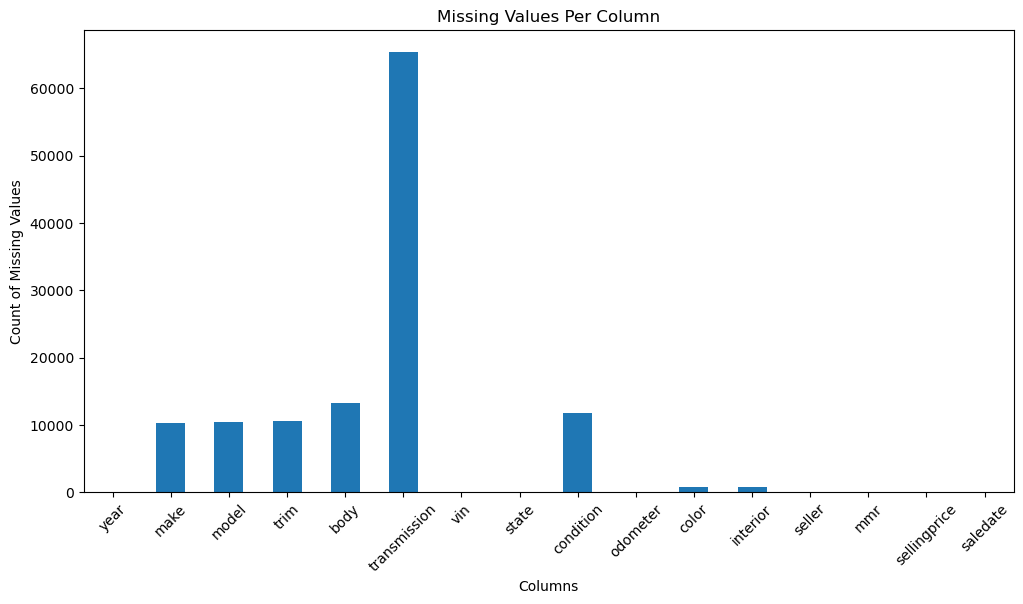

In [10]:
plt.figure(figsize=(12,6))
null_values.plot(kind='bar')
plt.title('Missing Values Per Column')
plt.xlabel('Columns')
plt.ylabel('Count of Missing Values')
plt.xticks(rotation=45)
plt.show() ## 1.3.A Visualize null values using Bar Chart

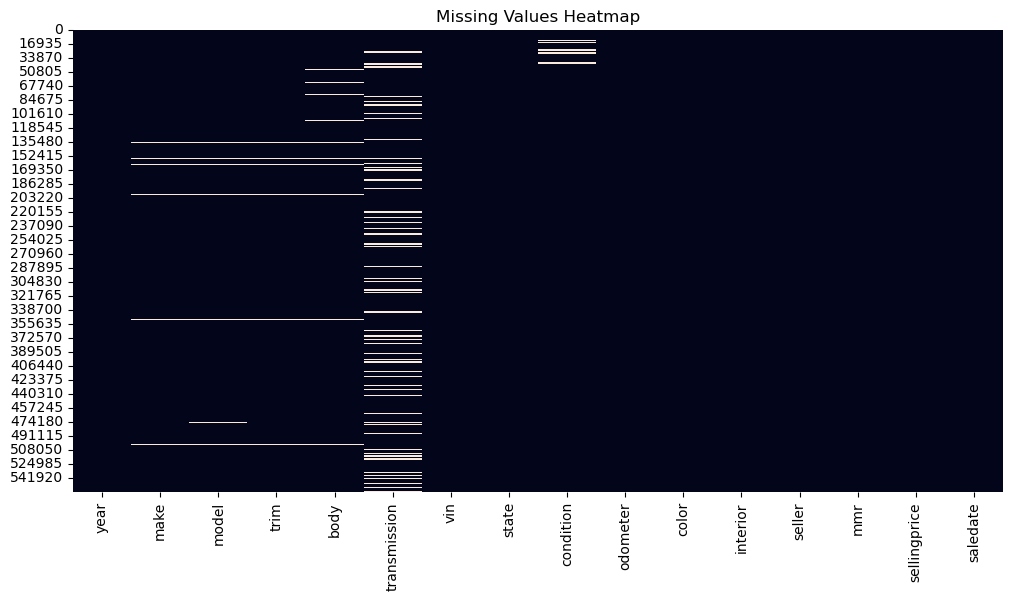

In [11]:
plt.figure(figsize=(12,6))
sns.heatmap(car_df.isnull(), cbar=False)
plt.title('Missing Values Heatmap')
plt.show()  ##  1.3.A Visualize null values using Heatmap

In [12]:
car_df.isnull().sum()/len(car_df)*100 ## Nulls per Coloumns percentage 1.3.B

year             0.000000
make             1.843292
model            1.860829
trim             1.905922
body             2.361154
transmission    11.694287
vin              0.000716
state            0.000000
condition        2.115107
odometer         0.016821
color            0.134028
interior         0.134028
seller           0.000000
mmr              0.006800
sellingprice     0.002147
saledate         0.002147
dtype: float64

In [13]:
duplicates =car_df.duplicated().sum()
print('Duplicate Records:', duplicates)  # Check duplicate records 1.3.c

Duplicate Records: 0


In [14]:
car_df = car_df.drop_duplicates()
print('Duplicates removed successfully')  # Drop duplicate records 1.3.c

Duplicates removed successfully


## 2. Data Frame Queries

In [15]:
car_df.describe()

,year,condition,odometer,mmr,sellingprice
count,558837.000000,547017.000000,558743.000000,558799.000000,558825.000000
mean,2010.038927,30.672365,68320.017767,13769.377495,13611.358810
std,3.966864,13.402832,53398.542821,9679.967174,9749.501628
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,23.000000,28371.000000,7100.000000,6900.000000
50%,2012.000000,35.000000,52254.000000,12250.000000,12100.000000
75%,2013.000000,42.000000,99109.000000,18300.000000,18200.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000


In [16]:
car_df['sellingprice'].agg(['mean','min','max'])  ## 2.1 Avg, Min, Max Price

mean     13611.35881
min          1.00000
max     230000.00000
Name: sellingprice, dtype: float64

In [17]:
car_df['color'].unique()  ##  2.2 List all unique colors of cars

array(['white', 'gray', 'black', 'red', 'silver', 'blue', 'brown',
       'beige', 'purple', 'burgundy', '—', 'gold', 'yellow', 'green',
       'charcoal', nan, 'orange', 'off-white', 'turquoise', 'pink',
       'lime', '4802', '9410', '1167', '2172', '14872', '12655', '15719',
       '6388', '16633', '11034', '2711', '6864', '339', '18384', '9887',
       '9837', '20379', '20627', '721', '6158', '2817', '5705', '18561',
       '2846', '9562', '5001'], dtype=object)

In [18]:
unique_brands = car_df['make'].nunique()
unique_models = car_df['model'].nunique()

In [19]:
print('Unique Car Brands:', unique_brands)
print('Unique Car Models:', unique_models) ## 2.3 Number of unique car brands and models

Unique Car Brands: 96
Unique Car Models: 973


In [20]:
car_df[car_df['sellingprice'] > 165000]  ## 2.4 all car information having selling prices greater than $165000

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
125095,2012,Rolls-Royce,Ghost,Base,Sedan,automatic,sca664s58cux50727,fl,45.0,14316.0,black,beige,braman motorcars,154000.0,169500.0,Wed Jan 14 2015 01:40:00 GMT-0800 (PST)
344905,2014,Ford,Escape,Titanium,SUV,automatic,1fmcu9j98eua23833,mo,43.0,27802.0,green,tan,ford-lincoln dealer program,22800.0,230000.0,Wed Feb 25 2015 02:00:00 GMT-0800 (PST)
446949,2015,Mercedes-Benz,S-Class,S65 AMG,Sedan,automatic,wddug7kb2fa102347,ca,41.0,5277.0,white,white,mercedes-benz usa,170000.0,173000.0,Thu May 21 2015 05:00:00 GMT-0700 (PDT)
538347,2012,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s59cux50803,ca,44.0,5215.0,white,tan,financial services remarketing (bmw int),166000.0,167000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)
545523,2013,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s52dux52152,fl,42.0,7852.0,white,beige,flag/landrover southpointe,178000.0,171500.0,Wed Jun 17 2015 03:05:00 GMT-0700 (PDT)
548169,2011,Ferrari,458 Italia,Base,coupe,automatic,zff67nfa1b0178698,fl,46.0,12116.0,red,black,platinum motor cars,182000.0,183000.0,Wed Jun 17 2015 03:40:00 GMT-0700 (PDT)
557570,2012,Rolls-Royce,Ghost,EWB,sedan,automatic,sca664l50cux65625,ca,36.0,11832.0,white,black,bentley scottsdale,164000.0,169000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)


In [21]:
car_df['model'].value_counts().head(5) ## 2.5  top 5 most frequently sold car models

model
Altima    19349
F-150     14479
Fusion    12946
Camry     12545
Escape    11861
Name: count, dtype: int64

In [22]:
car_df.groupby('make')['sellingprice'].mean().sort_values(ascending=False) ## 2.6 Average selling price by brand (make)

make
Rolls-Royce    153488.235294
Ferrari        127210.526316
Lamborghini    112625.000000
Bentley         74367.672414
airstream       71000.000000
                   ...      
dodge tk          550.000000
Geo               528.947368
dot               500.000000
ford truck        483.333333
Daewoo            400.000000
Name: sellingprice, Length: 96, dtype: float64

In [23]:
car_df.groupby('interior')['sellingprice'].min()    ## 2.7 minimum selling price of cars for each interior

interior
beige         100.0
black           1.0
blue          150.0
brown         200.0
burgundy      175.0
gold          250.0
gray            1.0
green         100.0
off-white     900.0
orange       1200.0
purple        200.0
red           200.0
silver        150.0
tan           100.0
white         350.0
yellow       3100.0
—             150.0
Name: sellingprice, dtype: float64

In [24]:
car_df.groupby('year')['odometer'].max().sort_values(ascending=False) ## 2.8 highest odometer reading per year from highest to lowest order

year
1999    999999.0
2013    999999.0
2011    999999.0
2010    999999.0
2009    999999.0
2008    999999.0
2007    999999.0
2006    999999.0
2005    999999.0
2004    999999.0
2003    999999.0
2002    999999.0
2001    999999.0
2014    999999.0
1998    999999.0
1997    999999.0
1996    999999.0
1993    999999.0
2012    999999.0
2000    462579.0
1995    396793.0
1992    379307.0
1994    356402.0
1991    274149.0
1986    273327.0
1990    265498.0
1988    241751.0
1987    230946.0
1989    218052.0
1984    170799.0
1985    121644.0
2015    100454.0
1982     85738.0
1983     42697.0
Name: odometer, dtype: float64

In [25]:
car_df['car_age'] = 2025 - car_df['year']

car_df[['year', 'car_age']].head()   ## 2.9 new column for car age

,year,car_age
0,2015,10
1,2015,10
2,2014,11
3,2015,10
4,2014,11


In [26]:
car_df[(car_df['condition'] >= 48) & (car_df['odometer'] > 90000)]  ## 2.10 Odometer Greater than 90000

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate,car_age
3230,2008,HUMMER,H3,Base,SUV,automatic,5gten13e588135632,ca,48.0,91132.0,black,beige,apexcars net,11950.0,15300.0,Wed Dec 17 2014 12:30:00 GMT-0800 (PST),17
3767,2006,Chevrolet,Silverado 1500,LS2,Crew Cab,automatic,2gcec13v561250941,ca,49.0,97742.0,white,gray,coast sports cars inc,8800.0,13250.0,Wed Dec 17 2014 12:15:00 GMT-0800 (PST),19
4365,2005,Toyota,4Runner,SR5,SUV,automatic,jtebu14rx50077814,ca,48.0,155887.0,gray,gray,san diego sports cars,6850.0,9500.0,Wed Dec 17 2014 12:15:00 GMT-0800 (PST),20
6743,2010,Mercedes-Benz,M-Class,ML350 BlueTEC,SUV,automatic,4jgbb2fb8aa608119,ca,49.0,92966.0,—,black,clear view systems,19550.0,19250.0,Tue Dec 23 2014 12:30:00 GMT-0800 (PST),15
9814,2011,Honda,Accord,EX V-6,Sedan,automatic,5kbcp3f7xbb001435,in,48.0,93763.0,gray,gray,primeritus remarketing/new concepts leasi,11450.0,9000.0,Thu Dec 18 2014 10:00:00 GMT-0800 (PST),14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
554633,2007,Acura,MDX,Base,suv,automatic,2hnyd28497h546449,ca,48.0,113131.0,gray,gray,california auto wholesale,12450.0,15500.0,Wed Jun 17 2015 05:30:00 GMT-0700 (PDT),18
554693,2007,HUMMER,H3,Base,suv,automatic,5gtdn13e178219652,wa,48.0,113993.0,blue,beige,remarketing by ge/manheim dallas,10950.0,9500.0,Wed Jun 17 2015 05:00:00 GMT-0700 (PDT),18
556010,2008,Ford,F-350 Super Duty,XLT,crew cab,automatic,1ftww31rx8ed16463,pa,48.0,92268.0,charcoal,beige,r hollenshead auto sales inc,18850.0,23400.0,Fri Jun 19 2015 02:00:00 GMT-0700 (PDT),17
556929,2010,GMC,Acadia,SLT-2,suv,NaN,1gklvned1aj221405,pa,49.0,113337.0,burgundy,beige,jones dealerships inc,14300.0,13100.0,Fri Jun 19 2015 02:00:00 GMT-0700 (PDT),15


In [27]:
newer_cars = car_df[car_df['year'] > 2013]

state_prices = newer_cars.groupby('state')['sellingprice'].mean().sort_values(ascending=False)

print(state_prices)  ## 2.11 higher car prices for newer cars(year>2013)

state
oh                   28020.221053
ab                   25204.255319
nj                   24237.063973
on                   22962.560386
qc                   22722.938144
                         ...     
3vwd17aj5fm225953    13200.000000
3vwd17aj8fm239622    13200.000000
3vwd17aj4fm201708    13200.000000
3vwd17aj3fm276741    13200.000000
ok                   10600.000000
Name: sellingprice, Length: 64, dtype: float64


In [28]:
condition_threshold = car_df['condition'].quantile(0.80)

excellent_cars = car_df[car_df['condition'] >= condition_threshold]

value_for_money = excellent_cars.groupby('make')['sellingprice'].mean().sort_values()

print(value_for_money.head(10))  ## 2.12  Top 20% Excellent Condition Cars

make
Isuzu         1125.000000
Oldsmobile    1910.000000
honda         4233.333333
Saturn        5700.406504
subaru        6200.000000
chrysler      6225.000000
smart         6835.759494
mazda         7275.000000
Pontiac       7686.824324
Saab          7711.111111
Name: sellingprice, dtype: float64


##  Data Visualization

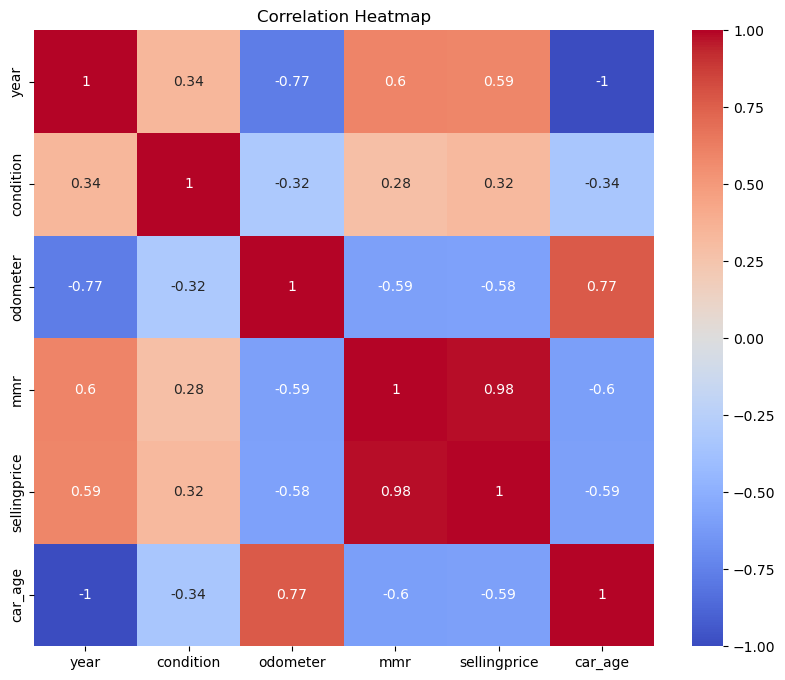

In [31]:
numeric_df = car_df.select_dtypes(include=['int64', 'float64'])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show() ## 3.1   correlation of all the features(columns) having numerical values

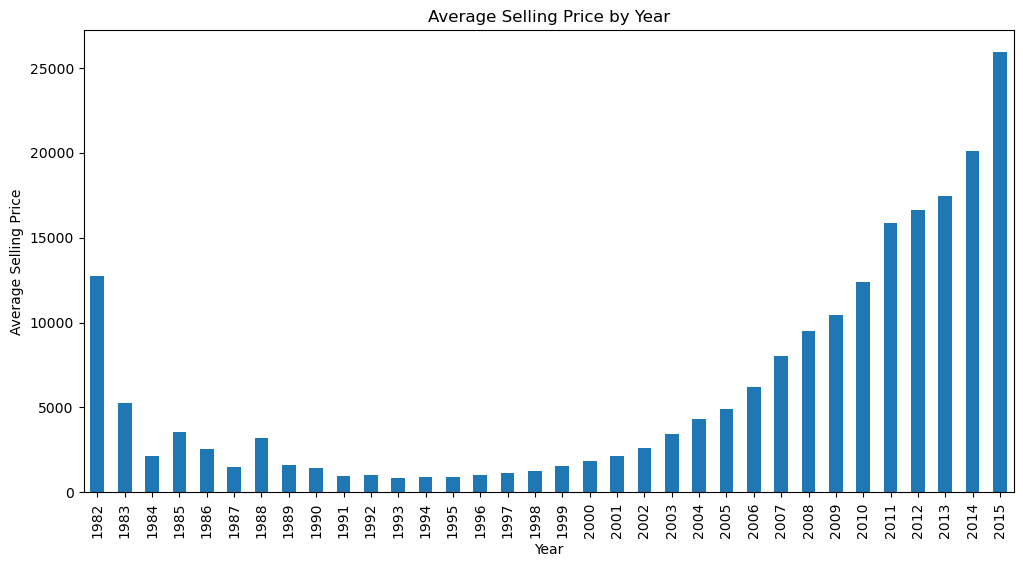

In [30]:
avg_price_year = car_df.groupby('year')['sellingprice'].mean()

plt.figure(figsize=(12,6))
avg_price_year.plot(kind='bar')
plt.title('Average Selling Price by Year')
plt.xlabel('Year')
plt.ylabel('Average Selling Price')
plt.show()    ## 3.2  Average Selling Price by Year

C:\Users\Dell\AppData\Local\Temp\ipykernel_14124\1576252535.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  odometer_price = car_df.groupby(pd.cut(car_df['odometer'], bins=10))['sellingprice'].mean()


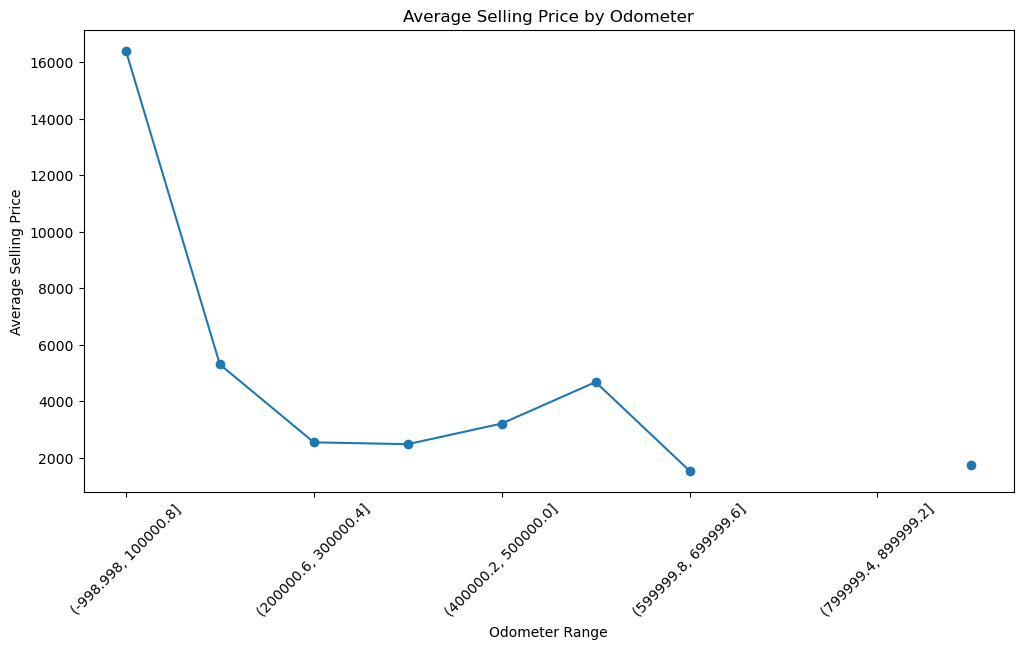

In [32]:
odometer_price = car_df.groupby(pd.cut(car_df['odometer'], bins=10))['sellingprice'].mean()

plt.figure(figsize=(12,6))
odometer_price.plot(kind='line', marker='o')
plt.title('Average Selling Price by Odometer')
plt.xlabel('Odometer Range')
plt.ylabel('Average Selling Price')
plt.xticks(rotation=45)
plt.show()  ## 3.3  Average Selling Price by Odometer

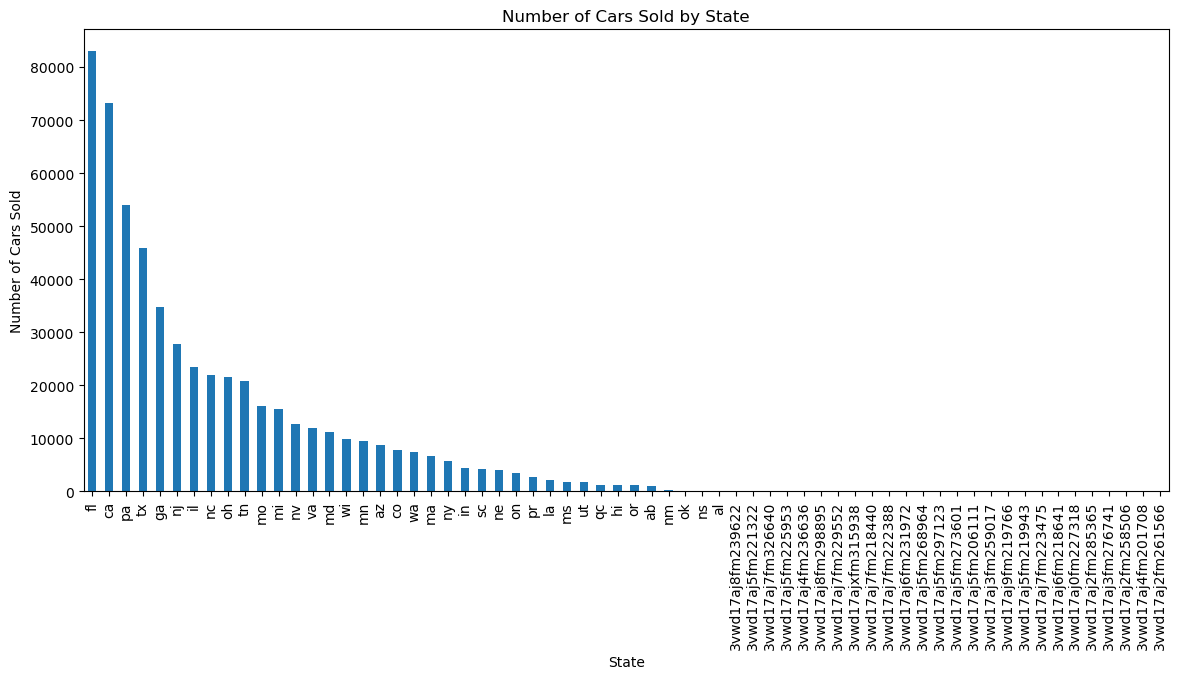

In [33]:
state_sales = car_df['state'].value_counts()

plt.figure(figsize=(14,6))
state_sales.plot(kind='bar')
plt.title('Number of Cars Sold by State')
plt.xlabel('State')
plt.ylabel('Number of Cars Sold')
plt.show()  ## 3.4 Number of Cars Sold in Each State

In [34]:
print(state_sales.head(3)) ## 3.4 Top 3 States

state
fl    82945
ca    73148
pa    53907
Name: count, dtype: int64


C:\Users\Dell\AppData\Local\Temp\ipykernel_14124\1344543387.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  condition_price = car_df.groupby(condition_bins)['sellingprice'].mean()


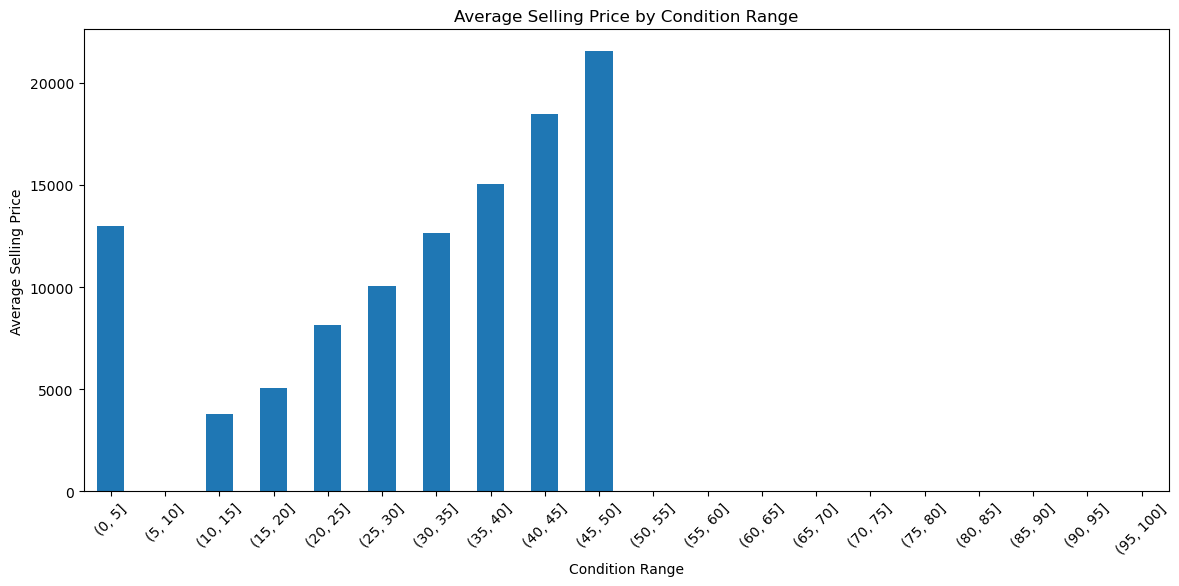

In [35]:
condition_bins = pd.cut(car_df['condition'], bins=range(0, 105, 5))

condition_price = car_df.groupby(condition_bins)['sellingprice'].mean()

plt.figure(figsize=(14,6))
condition_price.plot(kind='bar')
plt.title('Average Selling Price by Condition Range')
plt.xlabel('Condition Range')
plt.ylabel('Average Selling Price')
plt.xticks(rotation=45)
plt.show()   ## 3.5   Average Selling Price by Condition Range

In [ ]:
Insights

Better condition cars achieve higher prices.

Poor condition vehicles have significantly lower resale values.


C:\Users\Dell\AppData\Local\Temp\ipykernel_14124\4254577570.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  condition_sales = car_df.groupby(condition_count_bins).size()


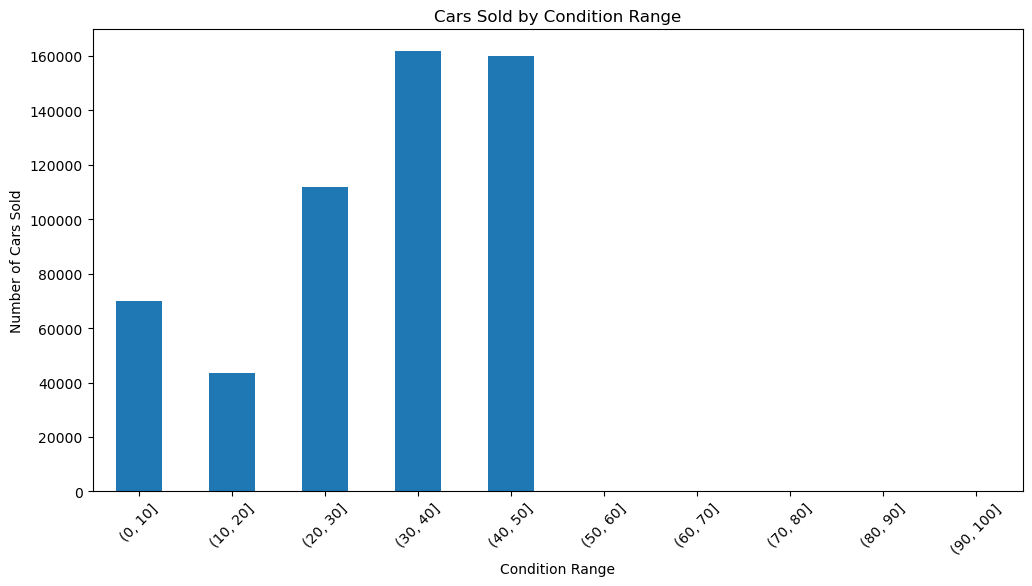

In [37]:
condition_count_bins = pd.cut(car_df['condition'], bins=range(0, 110, 10))
condition_sales = car_df.groupby(condition_count_bins).size()
plt.figure(figsize=(12,6))
condition_sales.plot(kind='bar')
plt.title('Cars Sold by Condition Range')
plt.xlabel('Condition Range')
plt.ylabel('Number of Cars Sold')
plt.xticks(rotation=45)
plt.show()   ## 3.6 Number of Cars Sold by Condition Range

In [ ]:
Insights

Most sold cars are usually in mid-to-good condition.

Extremely poor or excellent condition vehicles are fewer in number.

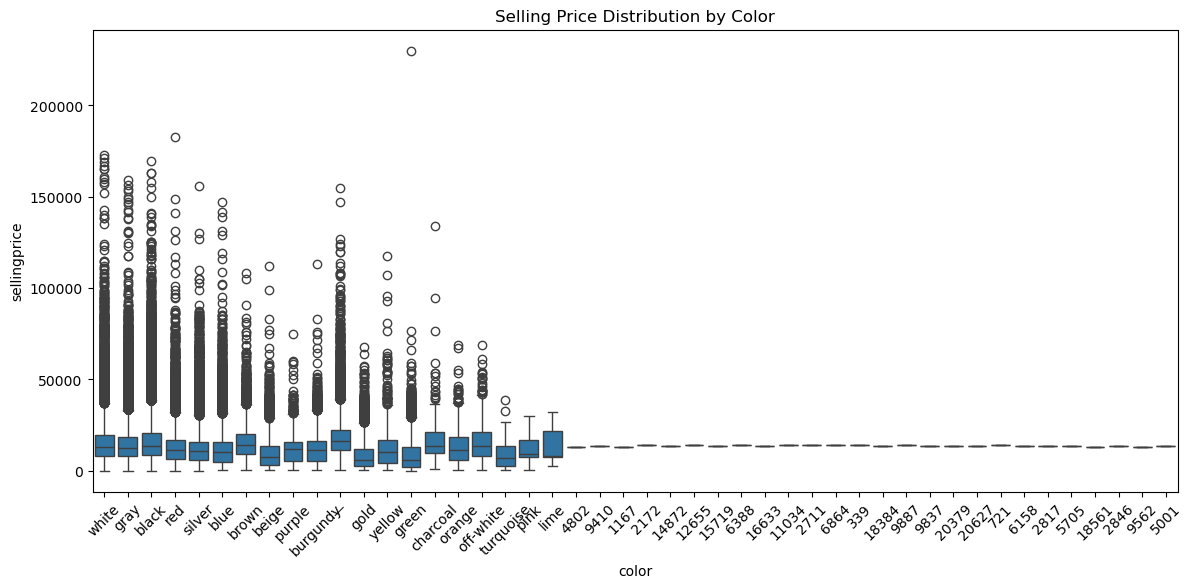

In [38]:
plt.figure(figsize=(14,6))
sns.boxplot(x='color', y='sellingprice', data=car_df)
plt.title('Selling Price Distribution by Color')
plt.xticks(rotation=45)
plt.show()  ## 3.7 Box Plot of Selling Prices by Color

In [ ]:
Insights

Some colors may show higher median selling prices.

Outliers indicate luxury or rare vehicles.

In [ ]:
Final Business Insights

Key Findings

1. Selling price strongly depends on:

Car year

Condition

Mileage (odometer)

Brand

2. Cars with:

Lower mileage

Better condition

Newer manufacturing year typically sell at higher prices.

3. Luxury brands usually maintain higher resale value.

4. Certain states have significantly larger automobile markets.

5. Odometer and selling price show an inverse relationship.